### Лабораторная работа №2: **Выделение именованных сущностей с использованием библиотеки spaCy**

#### Теоретическая часть

**Выделение именованных сущностей (NER)** – это процесс идентификации и классификации именованных сущностей в тексте, таких как имена людей, организации, места, даты и т.д. Библиотека `spaCy` предоставляет мощные инструменты для выполнения этой задачи.

#### Практическая задача

Используя корпус данных новостей, выполните следующую последовательность шагов:

1. Установите и импортируйте библиотеку `spaCy`.
2. Загрузите предварительно обученную модель английского языка (`en_core_web_sm`).
3. Предобработайте текст: удалите лишние символы, проведите токенизацию.
4. Выполните NER на каждом документе.
5. Сохраните результаты в формате JSON или CSV.
6. Проанализируйте полученные данные и найдите наиболее часто встречающиеся сущности.

#### Указания по выполнению

1. Используйте функцию `nlp.pipe()` для пакетной обработки документов.
2. Экспериментируйте с различными моделями `spaCy`, чтобы найти лучшую производительность.
3. Постройте график распределения частот именованных сущностей.
4. Подготовьте отчет, включающий код, примеры выделенных сущностей и анализ полученных результатов.

In [6]:
pip install --upgrade pip

  Using cached https://files.pythonhosted.org/packages/c9/bc/b7db44f5f39f9d0494071bddae6880eb645970366d0a200022a1a93d57f5/pip-25.0.1-py3-none-any.whl
  Found existing installation: pip 19.2.3
    Uninstalling pip-19.2.3:
      Successfully uninstalled pip-19.2.3
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install spacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.3 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... error
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [105 lines of output]
      Ignoring numpy: markers 'python_version >= "3.9"' don't match your environment
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finished with status 'done'
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Preparing m

In [8]:
pip install pandas 

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [12]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 1.7 MB/s eta 0:00:0000:0100:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 2.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import time
from collections import Counter

import spacy
nlp = spacy.load("en_core_web_sm")

: 

In [8]:
df = pd.concat((pd.read_csv('test.csv'),
                 pd.read_csv('train.csv')))
df = df[:5000]
df.head()

,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


In [9]:
df['full_text'] = df['Title'] + " " + df['Description']
df = df.drop(columns=['Title', 'Description'])
df.head()

,Class Index,full_text
0,3,Fears for T N pension after talks Unions repre...
1,4,The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Calif. Aims to Limit Farm-Related Smog (AP) AP...


In [10]:
def clean_text(text):
    text = re.sub(r'\\', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['full_text'].apply(clean_text)

## en_core_web_sm

In [12]:
entities = []
entity_counter = defaultdict(int)

for text in tqdm(df['clean_text'], desc="Processing NER"):
    doc = nlp(text)
    for ent in doc.ents:
        entities.append({
            "text": ent.text,
            "label": ent.label_,
            "class": df.loc[df['clean_text'] == text, 'Class Index'].values[0]
        })
        entity_counter[ent.label_] += 1

Processing NER: 100%|██████████████████████| 5000/5000 [00:38<00:00, 131.29it/s]


In [ ]:
def convert(o):
    if isinstance(o, np.integer):
        return int(o)
    elif isinstance(o, np.floating):
        return float(o)
    elif isinstance(o, np.ndarray):
        return o.tolist()
    else:
        raise TypeError(f"{type(o)} is not JSON serializable")

with open("ner_results.json", "w") as f:
    json.dump(entities, f, indent=2, default=convert)

In [13]:
print("Топ-5 сущностей:")
for label, count in sorted(entity_counter.items(), key=lambda x: -x[1])[:5]:
    print(f"{label}: {count}")

Топ-5 сущностей:
ORG: 6805
DATE: 4861
GPE: 4305
PERSON: 3810
CARDINAL: 3314


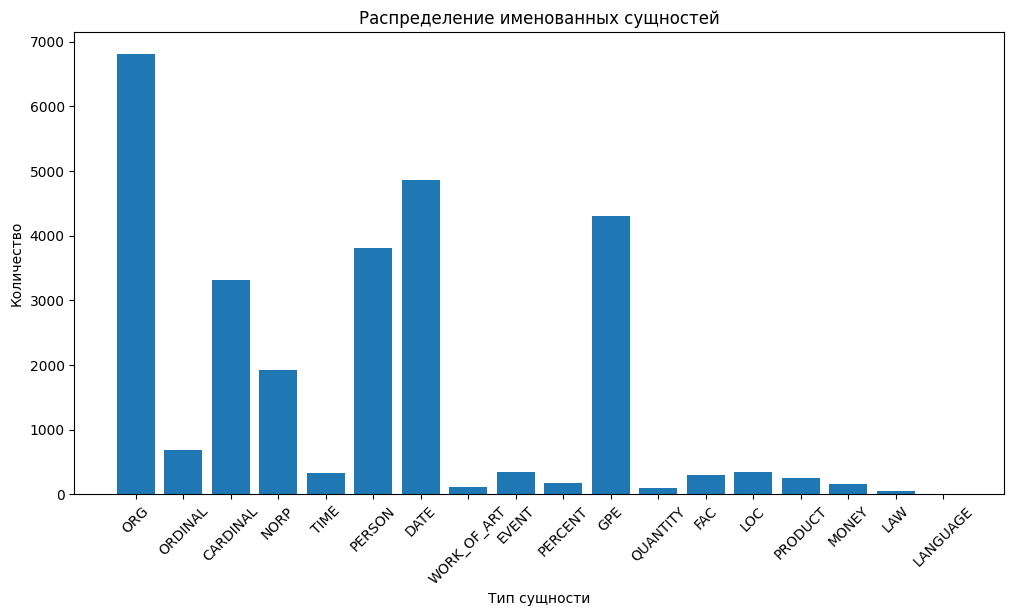

In [14]:
labels, counts = zip(*entity_counter.items())
plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.title("Распределение именованных сущностей")
plt.xlabel("Тип сущности")
plt.ylabel("Количество")
plt.xticks(rotation=45)
plt.show()

In [15]:
sample_doc = nlp(df['clean_text'][0])
print("Сущности в первой новости:")
for ent in sample_doc.ents:
    print(f"{ent.text} → {ent.label_}")

Сущности в первой новости:
Turner Newall → ORG
Federal Mogul → ORG


In [16]:
sci_tech_entities = [ent for ent in entities if ent["class"] == 3]
sci_tech_counter = defaultdict(int)
for ent in sci_tech_entities:
    sci_tech_counter[ent["label"]] += 1

print("Топ сущностей в Sci/Tech:")
for label, count in sorted(sci_tech_counter.items(), key=lambda x: -x[1])[:3]:
    print(f"{label}: {count}")

Топ сущностей в Sci/Tech:
ORG: 1965
DATE: 1386
CARDINAL: 788


## en_core_web_sm & en_core_web_lg

In [18]:
models = {
    "small": spacy.load("en_core_web_sm"),
    "large": spacy.load("en_core_web_lg")
}

def analyze_model(model_name, model, texts):
    print(f"Processing with {model_name}...")
    start_time = time.time()
    
    entities = []
    for doc in model.pipe(texts, batch_size=50):
        for ent in doc.ents:
            entities.append(ent.label_)
    
    elapsed_time = time.time() - start_time
    label_counts = Counter(entities)
    
    print(f"{model_name} completed in {elapsed_time:.2f} seconds.")
    print("Top entities:", label_counts.most_common(5))
    return label_counts, elapsed_time

results = {}
for name, model in tqdm(models.items()):
    results[name] = analyze_model(name, model, df['clean_text'])

labels_small = []
labels_large = []

for doc_sm, doc_lg in zip(models['small'].pipe(df['clean_text'], batch_size=50),
                          models['large'].pipe(df['clean_text'], batch_size=50)):
    ents_sm = [ent.label_ for ent in doc_sm.ents]
    ents_lg = [ent.label_ for ent in doc_lg.ents]
    labels_small.extend(ents_sm)
    labels_large.extend(ents_lg)

min_len = min(len(labels_small), len(labels_large))
matches = sum(1 for i in range(min_len) if labels_small[i] == labels_large[i])
percent_matches = matches / min_len * 100 if min_len > 0 else 0

print(f"Совпадение NER-меток по порядку: {percent_matches:.2f}%")

exact_matches = 0
total_texts = len(df['clean_text'])

for doc_sm, doc_lg in zip(models['small'].pipe(df['clean_text'], batch_size=50),
                          models['large'].pipe(df['clean_text'], batch_size=50)):
    ents_sm = set((ent.start_char, ent.end_char, ent.label_) for ent in doc_sm.ents)
    ents_lg = set((ent.start_char, ent.end_char, ent.label_) for ent in doc_lg.ents)
    
    if ents_sm == ents_lg:
        exact_matches += 1

print(f"Полное совпадение всех NER-entities в {exact_matches}/{total_texts} текстах ({exact_matches/total_texts*100:.2f}%)")

  0%|                                                     | 0/2 [00:00<?, ?it/s]

Processing with small...


 50%|██████████████████████▌                      | 1/2 [00:18<00:18, 18.37s/it]

small completed in 18.37 seconds.
Top entities: [('ORG', 6805), ('DATE', 4861), ('GPE', 4305), ('PERSON', 3810), ('CARDINAL', 3314)]
Processing with large...


100%|█████████████████████████████████████████████| 2/2 [00:38<00:00, 19.04s/it]

large completed in 19.71 seconds.
Top entities: [('ORG', 7915), ('DATE', 5000), ('GPE', 4857), ('PERSON', 3701), ('CARDINAL', 3359)]


Совпадение NER-меток по порядку: 15.58%
Полное совпадение всех NER-entities в 749/5000 текстах (14.98%)
